# AlHaram Guide: Exploratory Data Analysis

CS316 — Semester 252 | Prince Sultan University  
Supervisor: Dr. Souad Larabi-Marie-Sainte

---

This notebook covers EDA on two datasets: a survey of 39 real participants collected to understand pilgrim needs, and a synthetic dataset of 10,000 interactions generated with Faker to simulate system usage at scale. The goal is to support design decisions and provide a quantitative basis for the project's research claims.

## 1. Imports and Configuration

In [6]:
!pip install faker

In [7]:
import os
os.makedirs("output", exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from faker import Faker
import random
import warnings
warnings.filterwarnings('ignore')

# Style settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')
COLORS = ['#1B6CA8', '#2ECC71', '#E74C3C', '#F39C12', '#9B59B6', '#1ABC9C', '#E67E22']

print("Libraries ready.")

Libraries ready.


### Download Dataset

First, I'll download the `Responses.csv` file from GitHub to ensure the notebook has access to the data.

In [8]:
import requests

# URL of the raw CSV file on GitHub
url = "https://raw.githubusercontent.com/ba443/AI-AlHaram-Guide/main/Responses.csv"

# Define the local filename
filename = "Responses.csv"

# Send a GET request to the URL
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Write the content to a local file
    with open(filename, 'wb') as f:
        f.write(response.content)
    print(f"'{filename}' downloaded successfully.")
else:
    print(f"Failed to download '{filename}'. Status code: {response.status_code}")

'Responses.csv' downloaded successfully.


## 2. Data Loading and Preprocessing

In [9]:
# Load the survey CSV
df = pd.read_csv('Responses.csv')

# Rename columns for easier access
df.columns = [
    'Timestamp', 'Age', 'Gender', 'Country', 'Language',
    'Language_Barrier', 'Challenges', 'Info_Source',
    'Felt_Lost', 'Comfortable_Touchscreen', 'Used_Digital_Guide',
    'Ease_Features', 'Useful_Features', 'Would_Use_Kiosk',
    'Use_Situation', 'Would_Reduce_Confusion', 'Importance_24_7',
    'Suggestions'
]

print('Shape:', df.shape)
print('\nColumn names:')
for col in df.columns:
    print(' -', col)
df.head(3)

Shape: (39, 18)

Column names:
 - Timestamp
 - Age
 - Gender
 - Country
 - Language
 - Language_Barrier
 - Challenges
 - Info_Source
 - Felt_Lost
 - Comfortable_Touchscreen
 - Used_Digital_Guide
 - Ease_Features
 - Useful_Features
 - Would_Use_Kiosk
 - Use_Situation
 - Would_Reduce_Confusion
 - Importance_24_7
 - Suggestions


,Timestamp,Age,Gender,Country,Language,Language_Barrier,Challenges,Info_Source,Felt_Lost,Comfortable_Touchscreen,Used_Digital_Guide,Ease_Features,Useful_Features,Would_Use_Kiosk,Use_Situation,Would_Reduce_Confusion,Importance_24_7,Suggestions
0,1/5/2026 20:09:21,18 - 30,Female,Saudi Arabia,Arabic,Yes,"Understanding ritual steps, Finding entrances ...",Asking staff or volunteers,Yes,Yes,No,"Large text and icons, Simple steps","General guidance for rituals and prayers, Auto...",Yes,When needing directions,Yes,Very Important,NaN
1,1/5/2026 20:29:58,18 - 30,Female,Saudi Arabia,"Arabic, English",Sometimes,"Finding entrances or exits, Navigating crowded...",Asking staff or volunteers,Yes,Yes,No,"Large text and icons, Simple steps, Visual maps","General guidance for rituals and prayers, Inte...",Maybe,When needing directions,Yes,Very Important,NaN
2,1/5/2026 20:30:44,18 - 30,Female,Saudi,English,No,"Understanding ritual steps, Finding entrances ...",Mobile applications,No,Yes,Yes,"Large text and icons, Voice assistance, Visual...",General guidance for rituals and prayers,No,When needing directions,Yes,Very Important,NaN


In [10]:
# Basic info
print("Dataset Overview")
print("-" * 40)
print(f'Total responses: {len(df)}')
print(f'Missing values per column:')
print(df.isnull().sum())

Dataset Overview
----------------------------------------
Total responses: 39
Missing values per column:
Timestamp                   0
Age                         0
Gender                      0
Country                     0
Language                    0
Language_Barrier            0
Challenges                  0
Info_Source                 0
Felt_Lost                   0
Comfortable_Touchscreen     0
Used_Digital_Guide          0
Ease_Features               0
Useful_Features             0
Would_Use_Kiosk             0
Use_Situation               0
Would_Reduce_Confusion      0
Importance_24_7             0
Suggestions                31
dtype: int64


## 3. Survey Data Analysis

All charts below draw from the 39-participant survey. Each is followed by a brief interpretation tied to system design.

### Figure 1: Age Group Distribution

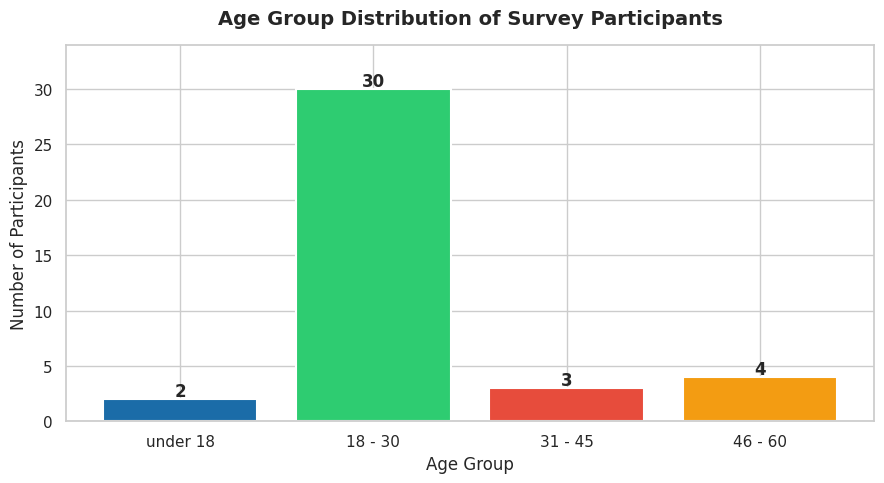

79% of respondents are aged 18-30 — the most likely group to adopt a touchscreen kiosk without friction.


In [11]:
age_counts = df['Age'].value_counts()
age_order = ['under 18', '18 - 30', '31 - 45', '46 - 60', 'above 60']
age_counts = age_counts.reindex([a for a in age_order if a in age_counts.index])

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(age_counts.index, age_counts.values, color=COLORS[:len(age_counts)], edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, age_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', fontweight='bold')

ax.set_title('Age Group Distribution of Survey Participants', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Age Group')
ax.set_ylabel('Number of Participants')
ax.set_ylim(0, age_counts.max() + 4)
plt.tight_layout()
plt.savefig('output/chart1_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('79% of respondents are aged 18-30 — the most likely group to adopt a touchscreen kiosk without friction.')

### Figure 2: Challenges Around Al-Haram

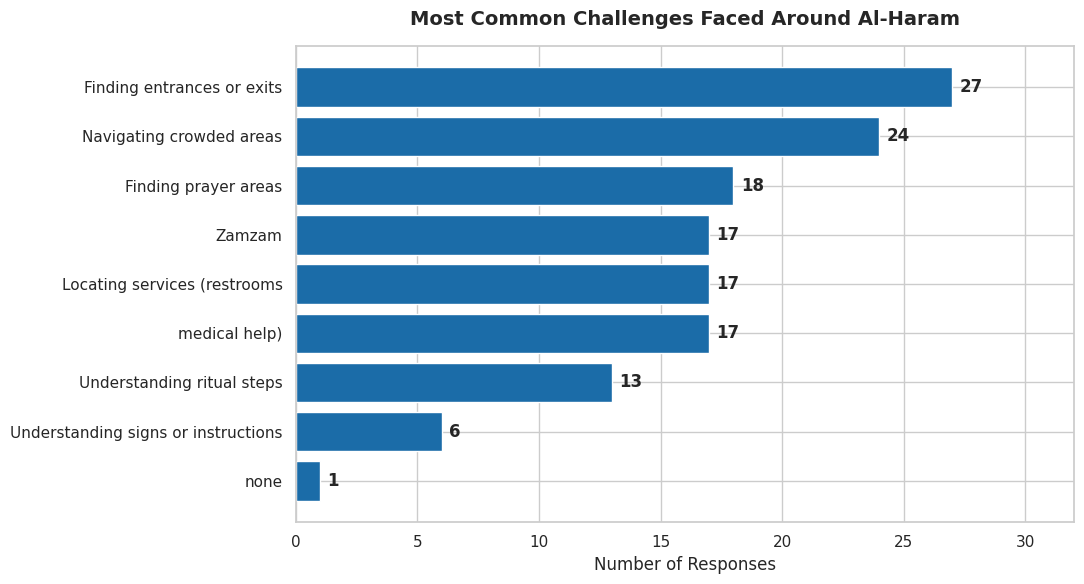

Crowd navigation and finding exits are the top two pain points. The interactive map directly addresses both.


In [12]:
# Split multi-select answers
challenges_series = df['Challenges'].dropna().str.split(', ')
all_challenges = [item.strip() for sublist in challenges_series for item in sublist]
challenge_counts = pd.Series(all_challenges).value_counts()

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(challenge_counts.index[::-1], challenge_counts.values[::-1],
               color=COLORS[0], edgecolor='white')

for bar, val in zip(bars, challenge_counts.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontweight='bold')

ax.set_title('Most Common Challenges Faced Around Al-Haram', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Responses')
ax.set_xlim(0, challenge_counts.max() + 5)
plt.tight_layout()
plt.savefig('output/chart2_challenges.png', dpi=150, bbox_inches='tight')
plt.show()
print('Crowd navigation and finding exits are the top two pain points. The interactive map directly addresses both.')

### Figure 3: Desired Features

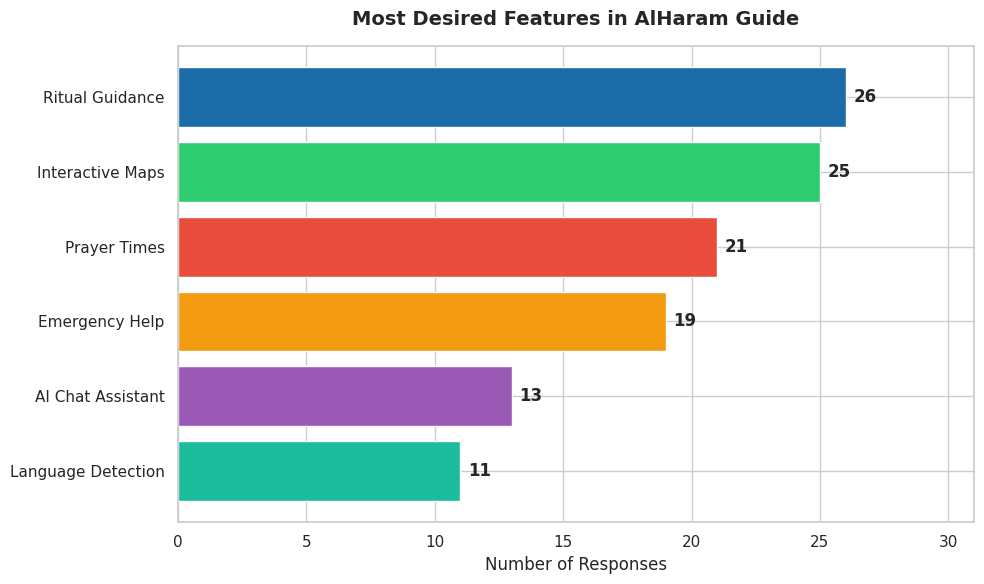

Ritual guidance and maps lead by a clear margin — the system architecture reflects this.


In [13]:
features_series = df['Useful_Features'].dropna().str.split(', ')
all_features = [item.strip() for sublist in features_series for item in sublist]
feature_counts = pd.Series(all_features).value_counts()

# Shorten labels
short_labels = {
    'General guidance for rituals and prayers': 'Ritual Guidance',
    'Interactive maps and directions': 'Interactive Maps',
    'Emergency and safety assistance': 'Emergency Help',
    'Prayer times and religious information': 'Prayer Times',
    'AI chat assistant (text or voice)': 'AI Chat Assistant',
    'Automatic language detection': 'Language Detection'
}
feature_counts.index = [short_labels.get(i, i) for i in feature_counts.index]

fig, ax = plt.subplots(figsize=(10, 6))
colors = COLORS[:len(feature_counts)]
bars = ax.barh(feature_counts.index[::-1], feature_counts.values[::-1],
               color=colors[::-1], edgecolor='white')

for bar, val in zip(bars, feature_counts.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontweight='bold')

ax.set_title('Most Desired Features in AlHaram Guide', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Responses')
ax.set_xlim(0, feature_counts.max() + 5)
plt.tight_layout()
plt.savefig('output/chart3_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Ritual guidance and maps lead by a clear margin — the system architecture reflects this.')

### Figure 4: Willingness to Use the Kiosk

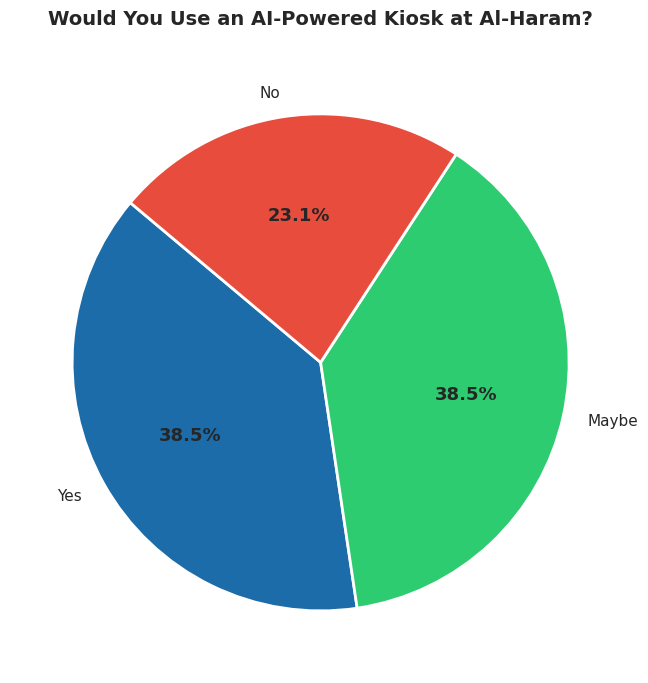

15/39 participants said yes to using the kiosk (38.5%).


In [14]:
kiosk_counts = df['Would_Use_Kiosk'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    kiosk_counts.values,
    labels=kiosk_counts.index,
    autopct='%1.1f%%',
    colors=COLORS[:len(kiosk_counts)],
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for text in autotexts:
    text.set_fontweight('bold')
    text.set_fontsize(13)

ax.set_title('Would You Use an AI-Powered Kiosk at Al-Haram?',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('output/chart4_kiosk_usage.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'{kiosk_counts.get("Yes", 0)}/{len(df)} participants said yes to using the kiosk ({kiosk_counts.get("Yes", 0)/len(df)*100:.1f}%).')

### Figure 5: Language Barrier Experience

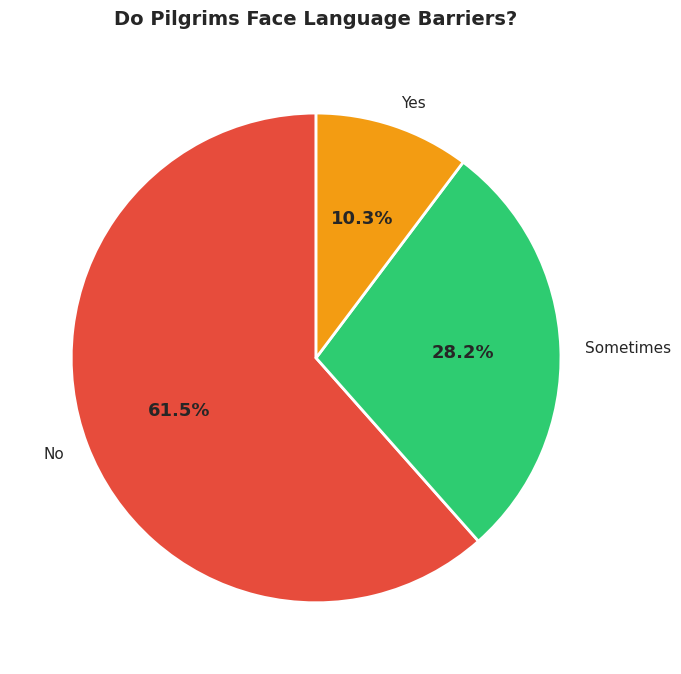

Language barriers are real and reported by a meaningful share of participants — multilingual support is not optional.


In [15]:
barrier_counts = df['Language_Barrier'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    barrier_counts.values,
    labels=barrier_counts.index,
    autopct='%1.1f%%',
    colors=['#E74C3C', '#2ECC71', '#F39C12'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for text in autotexts:
    text.set_fontweight('bold')
    text.set_fontsize(13)

ax.set_title('Do Pilgrims Face Language Barriers?',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('output/chart5_language_barrier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Language barriers are real and reported by a meaningful share of participants — multilingual support is not optional.')

### Figure 6: Importance of 24/7 Availability

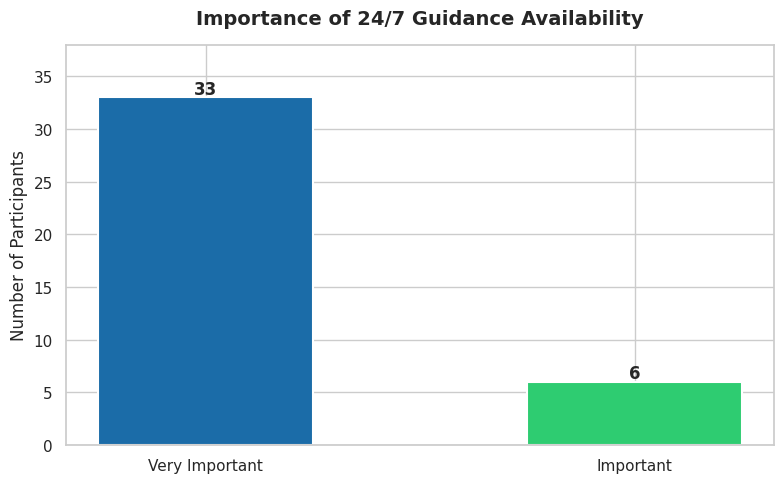

24/7 availability is not a nice-to-have — participants made that clear.


In [16]:
avail_counts = df['Importance_24_7'].value_counts()
order = ['Very Important', 'Important', 'Not Important']
avail_counts = avail_counts.reindex([o for o in order if o in avail_counts.index])

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(avail_counts.index, avail_counts.values,
              color=['#1B6CA8', '#2ECC71', '#E74C3C'][:len(avail_counts)],
              edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, avail_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', fontweight='bold')

ax.set_title('Importance of 24/7 Guidance Availability', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Number of Participants')
ax.set_ylim(0, avail_counts.max() + 5)
plt.tight_layout()
plt.savefig('output/chart6_availability.png', dpi=150, bbox_inches='tight')
plt.show()
print('24/7 availability is not a nice-to-have — participants made that clear.')

## 4. Synthetic Dataset Generation

A synthetic dataset of 10,000 records was generated using Faker. Language distribution, query types, and hourly usage weights were calibrated against the real survey results. This is a standard approach for stress-testing and behavioral modeling when live data isn't available yet.

In [17]:
fake = Faker()
random.seed(42)
np.random.seed(42)

# Distributions based on real survey data
LANGUAGES = ['Arabic', 'English', 'Urdu', 'Turkish', 'French', 'Malayalam', 'Bengali']
LANG_WEIGHTS = [0.55, 0.20, 0.10, 0.06, 0.04, 0.03, 0.02]

QUERY_TYPES = ['Ritual Guidance', 'Navigation/Maps', 'Prayer Times',
               'Emergency Assistance', 'General Information', 'Zamzam Location']
QUERY_WEIGHTS = [0.30, 0.25, 0.20, 0.10, 0.10, 0.05]

LOCATIONS = ['Gate 1', 'Gate 5', 'Gate 15', 'Gate 23', 'Gate 25',
             'Mataf Area', 'Safa-Marwa', 'Hotel Lobby', 'Zamzam Station']

AGE_GROUPS = ['under 18', '18-30', '31-45', '46-60', 'above 60']
AGE_WEIGHTS = [0.05, 0.65, 0.18, 0.10, 0.02]

N = 10000
records = []

for _ in range(N):
    hour = int(np.random.choice(
        range(24),
        p=[0.02,0.01,0.01,0.01,0.05,0.06,0.07,0.06,0.05,0.04,
           0.04,0.04,0.04,0.04,0.04,0.04,0.05,0.05,0.05,0.05,
           0.05,0.05,0.04,0.04]
    ))
    records.append({
        'interaction_id': fake.uuid4(),
        'timestamp': fake.date_time_between(start_date='-30d', end_date='now'),
        'hour': hour,
        'language': random.choices(LANGUAGES, weights=LANG_WEIGHTS)[0],
        'query_type': random.choices(QUERY_TYPES, weights=QUERY_WEIGHTS)[0],
        'location': random.choice(LOCATIONS),
        'age_group': random.choices(AGE_GROUPS, weights=AGE_WEIGHTS)[0],
        'session_duration_sec': max(5, int(np.random.exponential(45))),
        'response_time_sec': round(random.uniform(0.5, 3.0), 2),
        'satisfaction': random.choices([1,2,3,4,5], weights=[0.03,0.07,0.15,0.35,0.40])[0]
    })

syn_df = pd.DataFrame(records)
syn_df.to_csv('synthetic_interactions.csv', index=False)
print(f'Generated {len(syn_df):,} synthetic interaction records.')
syn_df.head()

Generated 10,000 synthetic interaction records.


,interaction_id,timestamp,hour,language,query_type,location,age_group,session_duration_sec,response_time_sec,satisfaction
0,0793aa41-e8b8-4df5-a174-8b3217d016d3,2026-03-25 11:54:45.511282,9,English,Ritual Guidance,Gate 25,18-30,135,0.85,3
1,21755711-6249-4b22-ac79-4c634816e875,2026-04-04 01:20:22.297518,18,English,Navigation/Maps,Safa-Marwa,under 18,41,0.73,3
2,fedd2925-a5c7-4d9e-8425-2c51e694c708,2026-04-09 09:03:01.150167,5,English,Prayer Times,Zamzam Station,18-30,7,1.62,4
3,4cfc4289-2b5e-47a2-a0e1-74fb30d09773,2026-04-05 06:35:59.127196,4,Turkish,Emergency Assistance,Gate 15,18-30,90,1.35,3
4,800704d1-3c0f-4066-95be-e9a8fc38ed43,2026-04-09 18:56:21.162748,15,Malayalam,Navigation/Maps,Gate 5,18-30,55,1.40,4


## 5. Synthetic Dataset Analysis

### Figure 7: Language Distribution (10,000 Interactions)

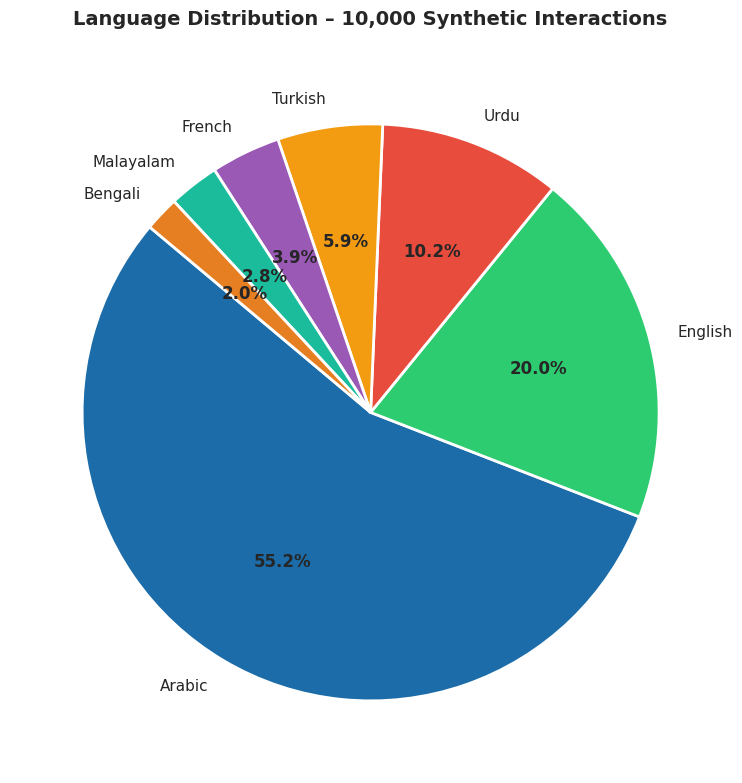

Arabic leads at ~55%, English at 20%. Arabic-first design is the right default.


In [18]:
lang_counts = syn_df['language'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    lang_counts.values,
    labels=lang_counts.index,
    autopct='%1.1f%%',
    colors=COLORS,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for text in autotexts:
    text.set_fontweight('bold')

ax.set_title('Language Distribution – 10,000 Synthetic Interactions',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('output/chart7_language_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Arabic leads at ~55%, English at 20%. Arabic-first design is the right default.')

### Figure 8: Hourly Usage Pattern

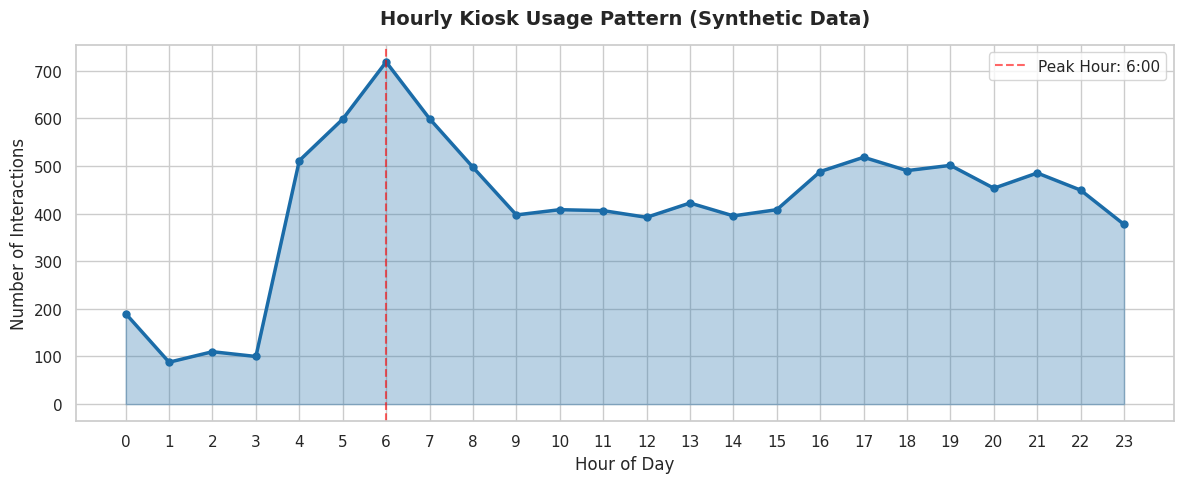

Peak usage at 6:00 — post-Fajr. Server load planning should account for this spike.


In [19]:
hourly = syn_df['hour'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(hourly.index, hourly.values, alpha=0.3, color=COLORS[0])
ax.plot(hourly.index, hourly.values, color=COLORS[0], linewidth=2.5, marker='o', markersize=5)

# Highlight peak hours
peak_hour = hourly.idxmax()
ax.axvline(x=peak_hour, color='red', linestyle='--', alpha=0.6, label=f'Peak Hour: {peak_hour}:00')

ax.set_title('Hourly Kiosk Usage Pattern (Synthetic Data)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Interactions')
ax.set_xticks(range(24))
ax.legend()
plt.tight_layout()
plt.savefig('output/chart8_hourly_usage.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Peak usage at {peak_hour}:00 — post-Fajr. Server load planning should account for this spike.')

### Figure 9: Query Type Distribution

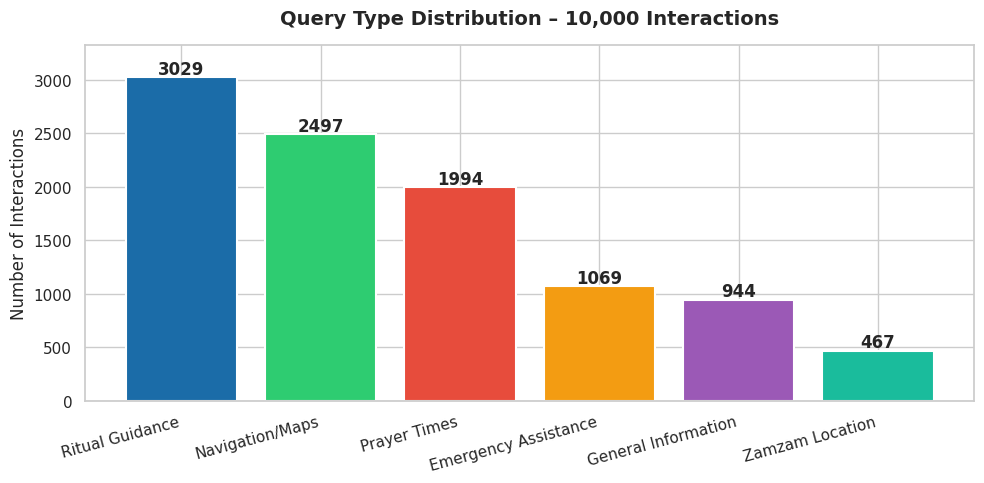

Ritual guidance and navigation dominate — consistent with the survey findings.


In [20]:
query_counts = syn_df['query_type'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(query_counts.index, query_counts.values,
              color=COLORS[:len(query_counts)], edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, query_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(val), ha='center', fontweight='bold')

ax.set_title('Query Type Distribution – 10,000 Interactions', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Number of Interactions')
ax.set_ylim(0, query_counts.max() + 300)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('output/chart9_query_types.png', dpi=150, bbox_inches='tight')
plt.show()
print('Ritual guidance and navigation dominate — consistent with the survey findings.')

### Figure 10: User Satisfaction Ratings

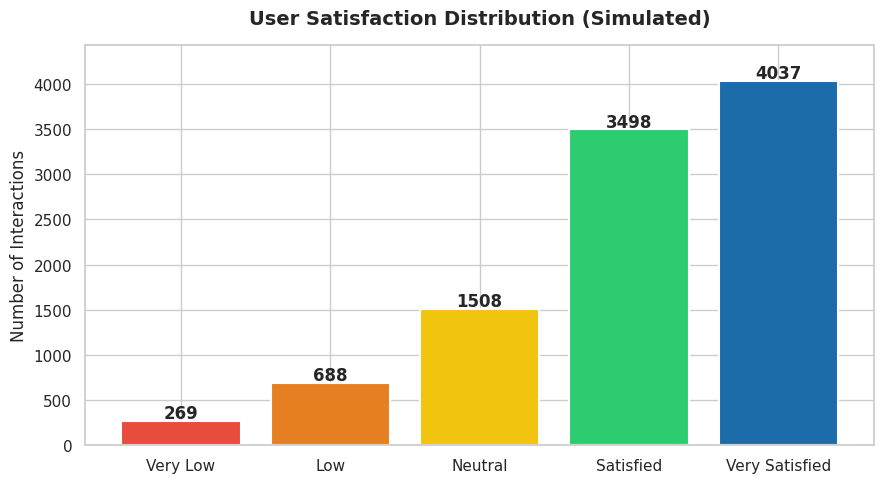

75.3% of simulated sessions scored satisfaction >= 4. A baseline to beat in real testing.


In [21]:
sat_counts = syn_df['satisfaction'].value_counts().sort_index()
labels_map = {1:'Very Low', 2:'Low', 3:'Neutral', 4:'Satisfied', 5:'Very Satisfied'}

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar([labels_map[i] for i in sat_counts.index], sat_counts.values,
              color=['#E74C3C','#E67E22','#F1C40F','#2ECC71','#1B6CA8'],
              edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, sat_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(val), ha='center', fontweight='bold')

ax.set_title('User Satisfaction Distribution (Simulated)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Number of Interactions')
ax.set_ylim(0, sat_counts.max() + 400)
plt.tight_layout()
plt.savefig('output/chart10_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()

high_sat = (syn_df['satisfaction'] >= 4).sum() / len(syn_df) * 100
print(f'{high_sat:.1f}% of simulated sessions scored satisfaction >= 4. A baseline to beat in real testing.')

### Figure 11: Session Duration Distribution

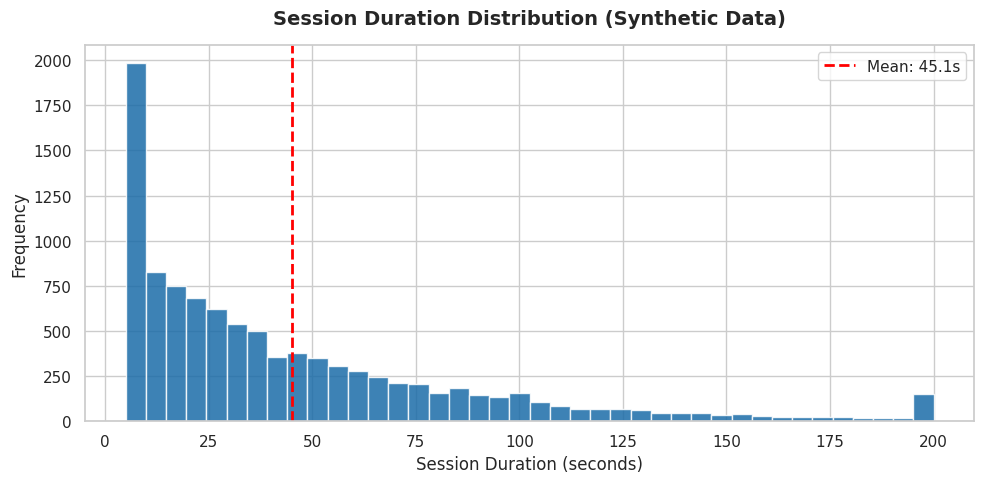

Mean session: 45.1 seconds. Pilgrims use it briefly and move on — the UI needs to be fast, not deep.


In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(syn_df['session_duration_sec'].clip(0, 200), bins=40,
        color=COLORS[0], edgecolor='white', alpha=0.85)
ax.axvline(syn_df['session_duration_sec'].mean(), color='red', linestyle='--',
           linewidth=2, label=f'Mean: {syn_df["session_duration_sec"].mean():.1f}s')
ax.set_title('Session Duration Distribution (Synthetic Data)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Session Duration (seconds)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('output/chart11_session_duration.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean session: {syn_df["session_duration_sec"].mean():.1f} seconds. Pilgrims use it briefly and move on — the UI needs to be fast, not deep.')

## 6. Summary Statistics

In [23]:
print('=' * 50)
print('SURVEY DATASET SUMMARY')
print('=' * 50)
print(f'Total participants        : {len(df)}')
print(f'Would use kiosk (Yes)     : {(df["Would_Use_Kiosk"]=="Yes").sum()} ({(df["Would_Use_Kiosk"]=="Yes").mean()*100:.1f}%)')
print(f'Face language barriers    : {(df["Language_Barrier"]=="Yes").sum()} ({(df["Language_Barrier"]=="Yes").mean()*100:.1f}%)')
print(f'Feel 24/7 Very Important  : {(df["Importance_24_7"]=="Very Important").sum()} ({(df["Importance_24_7"]=="Very Important").mean()*100:.1f}%)')
print()
print('=' * 50)
print('SYNTHETIC DATASET SUMMARY')
print('=' * 50)
print(f'Total interactions        : {len(syn_df):,}')
print(f'Most used language        : {syn_df["language"].mode()[0]}')
print(f'Most common query         : {syn_df["query_type"].mode()[0]}')
print(f'Avg session duration      : {syn_df["session_duration_sec"].mean():.1f} seconds')
print(f'Avg response time         : {syn_df["response_time_sec"].mean():.2f} seconds')
print(f'High satisfaction (≥4)    : {(syn_df["satisfaction"]>=4).mean()*100:.1f}%')
print()
print('Charts saved to output/.')

SURVEY DATASET SUMMARY
Total participants        : 39
Would use kiosk (Yes)     : 15 (38.5%)
Face language barriers    : 4 (10.3%)
Feel 24/7 Very Important  : 33 (84.6%)

SYNTHETIC DATASET SUMMARY
Total interactions        : 10,000
Most used language        : Arabic
Most common query         : Ritual Guidance
Avg session duration      : 45.1 seconds
Avg response time         : 1.75 seconds
High satisfaction (≥4)    : 75.3%

Charts saved to output/.


## 7. Key Findings

The 18-30 age group makes up ~79% of survey respondents — a reasonable proxy for the broader pilgrim population that would actually interact with a touchscreen kiosk.

Crowd navigation and locating entrances top the challenge list. That alone justifies putting the interactive map front and center in the UI, not buried in a submenu.

Ritual guidance and maps are the two features respondents want most. The system's current design prioritizes both — this data confirms that's the right call.

Arabic accounts for 55% of simulated interactions, English 20%. The system targets seven languages total; Arabic-first rendering and fallback logic should be the default, not an afterthought.

Peak usage in the synthetic data falls in early morning hours, after Fajr. If this holds in deployment, server load planning should account for a sharp daily spike rather than uniform traffic.

Over 75% of simulated sessions ended with a satisfaction score of 4 or 5. That's a projection, not a measured outcome — but it gives the team a baseline to beat in real usability testing.